In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [9]:
# ============================================================
# COMMON SETUP FOR Q5, Q6 AND Q7
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf

# Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Parameters
VOCAB_SIZE = 10000
MAX_LENGTH = 150
RNN_UNITS = 64
BATCH_SIZE = 64
EPOCHS = 10

print("TensorFlow version:", tf.__version__)
print("Random seed:", SEED)

TensorFlow version: 2.20.0
Random seed: 42


In [10]:
# ============================================================
# Q5 - IMDB SENTIMENT CLASSIFICATION USING SIMPLE RNN
# ============================================================

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ------------------------------------------------------------
# PADDING
# ------------------------------------------------------------

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


# ------------------------------------------------------------
# BUILD Q5 MODEL
# ------------------------------------------------------------

EMBEDDING_DIM = 64

q5_model = Sequential([
    
    tf.keras.Input(shape=(MAX_LENGTH,)),
    
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),
    
    SimpleRNN(
        RNN_UNITS,
        activation="tanh",
        dropout=0.2,
        recurrent_dropout=0.2
    ),
    
    Dropout(0.5),
    
    Dense(
        1,
        activation="sigmoid"
    )
])


# ------------------------------------------------------------
# COMPILE
# ------------------------------------------------------------

q5_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

q5_model.summary()


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

q5_history = q5_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)


# ------------------------------------------------------------
# TEST
# ------------------------------------------------------------

q5_loss, q5_accuracy = q5_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nQ5 FINAL RESULT")
print("=" * 40)
print(f"Test Loss: {q5_loss:.4f}")
print(f"Test Accuracy: {q5_accuracy:.4f}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
Training shape: (25000, 150)
Testing shape: (25000, 150)


I0000 00:00:1789226807.645575      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789226807.648474      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
  7/313 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.4499 - loss: 0.7955

I0000 00:00:1789226814.115306     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.5026 - loss: 0.7365 - val_accuracy: 0.5156 - val_loss: 0.6925
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5118 - loss: 0.7069 - val_accuracy: 0.5288 - val_loss: 0.6905
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5174 - loss: 0.6964 - val_accuracy: 0.5236 - val_loss: 0.6916
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5180 - loss: 0.6943 - val_accuracy: 0.5346 - val_loss: 0.6909

Q5 FINAL RESULT
Test Loss: 0.6914
Test Accuracy: 0.5209


In [11]:
# ============================================================
# Q6 - EFFECT OF EMBEDDING DIMENSION
# ============================================================

import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ------------------------------------------------------------
# EMBEDDING DIMENSIONS
# ------------------------------------------------------------

EMBEDDING_DIMS = [32, 64, 128]

q6_results = []
trained_models = {}


# ------------------------------------------------------------
# EXPERIMENT
# ------------------------------------------------------------

for embedding_dim in EMBEDDING_DIMS:

    print("\n" + "=" * 60)
    print(f"Embedding Dimension: {embedding_dim}")
    print("=" * 60)

    # Reset seeds
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    # Build model
    model = Sequential([

        tf.keras.Input(shape=(MAX_LENGTH,)),

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=embedding_dim,
            mask_zero=True
        ),

        SimpleRNN(
            RNN_UNITS,
            activation="tanh",
            dropout=0.2,
            recurrent_dropout=0.2
        ),

        Dropout(0.5),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Early stopping
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    # Train
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping],
        verbose=1
    )

    # Test
    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    # Store results
    q6_results.append({
        "Embedding Dimension": embedding_dim,
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy
    })

    # Save trained model
    trained_models[embedding_dim] = model

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")


# ------------------------------------------------------------
# FINAL COMPARISON
# ------------------------------------------------------------

q6_df = pd.DataFrame(q6_results)

print("\n\nQ6 FINAL COMPARISON")
print("=" * 60)
print(q6_df.to_string(index=False))


Embedding Dimension: 32
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.5094 - loss: 0.7294 - val_accuracy: 0.5054 - val_loss: 0.6938
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4969 - loss: 0.7109 - val_accuracy: 0.4988 - val_loss: 0.6934
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5112 - loss: 0.6979 - val_accuracy: 0.5154 - val_loss: 0.6922
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5109 - loss: 0.6947 - val_accuracy: 0.4998 - val_loss: 0.6934
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5149 - loss: 0.6937 - val_accuracy: 0.5082 - val_loss: 0.6928
Test Loss: 0.6925
Test Accuracy: 0.5151

Embedding Dimension: 64
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.5000 - loss: 0.7372 - val_accuracy: 0.5096 - val_loss: 0.6923
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5114 - loss: 0.7062 - val_accuracy: 0.5312 - val_loss: 0.6911
Epoch

Best Embedding Dimension: 64

Q7 - MODEL EVALUATION
Embedding Dimension: 64
Accuracy  : 0.7266
Precision : 0.7050
Recall    : 0.7793
F1-score  : 0.7403

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.67      0.71     12500
    Positive       0.70      0.78      0.74     12500

    accuracy                           0.73     25000
   macro avg       0.73      0.73      0.73     25000
weighted avg       0.73      0.73      0.73     25000


Confusion Matrix:
[[8423 4077]
 [2759 9741]]


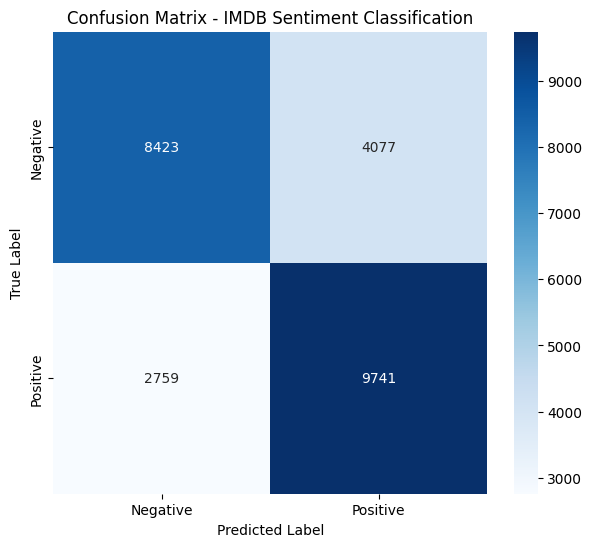

In [12]:
# ============================================================
# Q7 - EVALUATION OF BEST MODEL
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# 1. SELECT BEST MODEL FROM Q6
# ------------------------------------------------------------

best_embedding_dim = 64

best_model = trained_models[best_embedding_dim]

print("Best Embedding Dimension:", best_embedding_dim)


# ------------------------------------------------------------
# 2. GENERATE PREDICTIONS
# ------------------------------------------------------------

y_probability = best_model.predict(
    X_test,
    verbose=0
)

y_pred = (
    y_probability >= 0.5
).astype(int).flatten()


# ------------------------------------------------------------
# 3. CALCULATE EVALUATION METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


# ------------------------------------------------------------
# 4. DISPLAY METRICS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Q7 - MODEL EVALUATION")
print("=" * 60)

print(f"Embedding Dimension: {best_embedding_dim}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


# ------------------------------------------------------------
# 5. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 6. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ------------------------------------------------------------
# 7. PLOT CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - IMDB Sentiment Classification")

plt.show()